# DATA CLEANING & PREPARATION
- This notebook will be used to clean the data that will be used for this project.
- The data was obtained from ***https://ckan.africadatahub.org/dataset/kenya-femicide-data***
- In this notebook, we will clean standardize and normalize the data to prepare it for analysis in the EDA notebook.

In [82]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df = pd.read_excel("../Data/raw/kenya-femicide-data_2016_dec2023.xlsx")
df.head()

,url,title,author_name,medium,country_name,text,published_date,type of murder,name of victim,Age,...,Type of femicide,Murder Scene,Mode of killing,Circumstance,Status on article date,Court date (first appearance),verdict date,Verdict,Years of sentence,Days to verdict
0,http://www.standardmedia.co.ke/article/2000218...,Meru man who killed drunk wife sentenced to hang,Lydiah Nyawira,Standard Digital (Kenya),Kenya,"On August 12, 2005 at around 7pm, Joyce Gacher...",2016-10-05,Femicide,Dorcas Kaguri,Unknown,...,Intimate,home,blunt force,Argument,Unknown,2005-08-13 00:00:00,2016-06-24 00:00:00,Guilty,Death,4061
1,http://www.standardmedia.co.ke/article/2001300...,"Court: Kakamega man guilty of raping, killing ...",Jack Murima,Standard Digital (Kenya),Kenya,"Jack Murima - Sun, 28. October 2018 12:54 PM -...",2018-10-29,Femicide,Selina Ikambi Anasi,79,...,Non-intimate,Public Space,hacked,Unknown,Unknown,Unknown,2018-10-28 00:00:00,guilty,awaiting ruling,2817
2,http://www.standardmedia.co.ke/article/2001241...,My wife 'died from fall in fight over volume o...,Kamau Muthoni,Standard Digital (Kenya),Kenya,Former journalist Moses Dola Otieno yesterday ...,2017-05-25,Femicide,Wambui Kabiru,Unknown,...,Intimate,home,blunt force,Argument,Unknown,Unknown,2018-10-05 00:00:00,guilty,10,2714
3,http://www.nation.co.ke/news/Kabogo-cleared-Me...,Kabogo cleared in varsity student's murder case,ELISHA OTIENO,Daily Nation (Kenya),Kenya,Kiambu Governor Kabogo and five others adverse...,2016-10-07,Femicide,Mercy Keino,Unknown,...,Unknown,Public Space,Unknown,Unknown,Unknown,Unknown,2016-10-07 00:00:00,Not Guilty,Freed,1939
4,http://www.mediamaxnetwork.co.ke/news/pastor-t...,"Pastor to serve 25 years in jail for defiling,...",People Daily,MediaMax Network,Kenya,Musa Wekesa A pastor from Kitale has been sent...,2019-05-25,Femicide,Scholastica Mmbihi,Unknown,...,Unknown,home,stabbed,Argument,Unknown,Unknown,2019-05-25 00:00:00,guilty,25,2879


In [84]:
df.shape

(507, 24)

In [85]:
df.columns

Index(['url', 'title', 'author_name', 'medium', 'country_name', 'text',
       'published_date', 'type of murder', 'name of victim', 'Age',
       'date of murder', 'Location', 'name of suspect', 'suspect relationship',
       'Type of femicide', 'Murder Scene', 'Mode of killing', 'Circumstance',
       'Status on article date', 'Court date (first appearance)',
       'verdict date', 'Verdict', 'Years of sentence', 'Days to verdict'],
      dtype='object')

In [86]:
df.describe()

,published_date
count,479
mean,2020-04-23 07:24:55.615866624
min,2016-01-01 00:00:00
25%,2018-07-02 12:00:00
50%,2020-04-27 00:00:00
75%,2022-01-09 00:00:00
max,2023-12-06 00:00:00


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   url                            507 non-null    object        
 1   title                          479 non-null    object        
 2   author_name                    473 non-null    object        
 3   medium                         495 non-null    object        
 4   country_name                   492 non-null    object        
 5   text                           468 non-null    object        
 6   published_date                 479 non-null    datetime64[ns]
 7   type of murder                 507 non-null    object        
 8   name of victim                 507 non-null    object        
 9   Age                            507 non-null    object        
 10  date of murder                 507 non-null    object        
 11  Location           

In [88]:
# Check the number of missing values in each column
for col in df.columns:
    print(f'{col}: {df[col].isna().sum()}')

url: 0
title: 28
author_name: 34
medium: 12
country_name: 15
text: 39
published_date: 28
type of murder: 0
name of victim: 0
Age: 0
date of murder: 0
Location: 2
name of suspect: 39
suspect relationship: 2
Type of femicide: 59
Murder Scene: 0
Mode of killing: 0
Circumstance: 69
Status on article date: 71
Court date (first appearance): 99
verdict date: 0
Verdict: 101
Years of sentence: 102
Days to verdict: 0


### Filling Na VAlues column by column
Since we only 507 records rather than droping the Na values its better to fill them while keeping the integrity of the data

In [89]:
# Filling Title column with Femicide
df['title'] = df['title'].fillna('Femicide')

#Checking if there is still missing values in that column
df['title'].isna().sum()

np.int64(0)

In [90]:
# Filling authour name with unknown
df['author_name'] = df['author_name'].fillna('Unknown')
df['author_name'].isna().sum()

np.int64(0)

In [91]:
# Filling Medium with the most frequent value
df['medium'] = df['medium'].fillna(df['medium'].mode()[0])
df['medium'].isna().sum()

np.int64(0)

In [92]:
#Filling country_name with kenya
df['country_name'] = df['country_name'].fillna('Kenya')
df['country_name'].isna().sum()

np.int64(0)

In [93]:
df['text'] = df['text'].fillna('Femicide was committed')
df['text'].isna().sum()

np.int64(0)

In [94]:
df['published_date'] =  pd.to_datetime(df['published_date'])
df['published_date'][299]

Timestamp('2020-09-15 00:00:00')

In [95]:
#Filling missing published dates with Unkown
df['published_date'] = df['published_date'].fillna('Unknown')
df['published_date'].isna().sum()

np.int64(0)

In [96]:
# Location with Uknown
df['Location'] = df['Location'].fillna('Unknown')
df['Location'].isna().sum()

np.int64(0)

In [97]:
df['name of suspect'] = df['name of suspect'].fillna('Unknown')
df['name of suspect'].isna().sum()

np.int64(0)

In [98]:
df['suspect relationship'] = df['suspect relationship'].fillna('Unknown')
df['suspect relationship'].isna().sum()

np.int64(0)

In [99]:
#Type of femicide
df['Type of femicide'] = df['Type of femicide'].fillna('Unknown')
df['Type of femicide'].isna().sum()

np.int64(0)

In [100]:
df[['Circumstance', 'Status on article date', 'Court date (first appearance)', 'verdict date', 'Verdict',
'Years of sentence', 'Days to verdict']] = df[['Circumstance', 'Status on article date', 'Court date (first appearance)', 'verdict date', 'Verdict',
'Years of sentence', 'Days to verdict']].fillna('Unknown')

#Checking the whole dataset for mising values in each column
for col in df.columns:
    print(f'{col}: {df[col].isna().sum()}')

url: 0
title: 0
author_name: 0
medium: 0
country_name: 0
text: 0
published_date: 0
type of murder: 0
name of victim: 0
Age: 0
date of murder: 0
Location: 0
name of suspect: 0
suspect relationship: 0
Type of femicide: 0
Murder Scene: 0
Mode of killing: 0
Circumstance: 0
Status on article date: 0
Court date (first appearance): 0
verdict date: 0
Verdict: 0
Years of sentence: 0
Days to verdict: 0


- Once Null values have been filled we can now proceed to checking the data types  of each column and validate them
- I find the best way for this is to use value_counts() method to see if the data types do match the expected values

In [101]:
# Checking the top 5 values of each column
df['Age'].value_counts()

Age
Unknown    195
22          22
25          19
24          15
26          15
          ... 
48           1
52           1
11           1
66           1
47           1
Name: count, Length: 65, dtype: int64

In [102]:
df['Days to verdict'] = df['Days to verdict'].replace('#VALUE!', 'Uknown')
df['Days to verdict'].value_counts()

Days to verdict
Uknown    471
2817        1
2714        1
1939        1
4061        1
2879        1
3130        1
2468        1
3077        1
2694        1
2976        1
2820        1
2068        1
2507        1
1714        1
2315        1
2037        1
1309        1
2566        1
1361        1
2914        1
853         1
1738        1
1212        1
565         1
183         1
944         1
-84         1
1690        1
0           1
1662        1
708         1
308         1
-23         1
361         1
182         1
123         1
Name: count, dtype: int64

We can have two preprocessed version of the data:
1. **Data preprocessed for analysis**
    - This version requires the "unknown" data remain as is. For example if Age is unknown we keep it as unknown.
    - This will help keep data integrity for fact finding and deriving insights without baisness.
    - However for some columns such as victims name where we have unnamed which can also mean unknown we will replace it with unknown.
2. **Data preprocessed for forecasting**
    - This version requires the unknown data to be imputed. For example if Age is unknown we impute it with the mean age of the dataset.
    - This will help in maintaining the integrity of the data for forecasting models.

## DATA PREPARATION FOR ANALYSIS

In [103]:
df['name of victim'] = df['name of victim'].replace('Unknown', 'Unnamed')
df['name of victim'].value_counts().head()

name of victim
Unnamed             106
Margaret Wanjiru      2
Milca Mwangi          2
Lucy Atieno           2
Ann Njeri             2
Name: count, dtype: int64

We can extract the county from the location column and create a column called county to see the distribution of femicide cases by county.

In [104]:
df['Location'].value_counts().head()

Location
Naivasha, Nakuru county             6
Nakuru County                       4
Unknown                             4
Eldoret town, Uasin Gishu county    3
Gilgil, Nakuru County               3
Name: count, dtype: int64

In [105]:
# List of the 47 counties in Kenya
valid_counties = [
    'Mombasa', 'Kwale', 'Kilifi', 'Tana River', 'Lamu', 'Taita Taveta', 'Garissa', 'Wajir',
    'Mandera', 'Marsabit', 'Isiolo', 'Meru', 'Tharaka-Nithi', 'Embu', 'Kitui', 'Machakos',
    'Makueni', 'Nyandarua', 'Nyeri', 'Kirinyaga', 'Murang\'a', 'Kiambu', 'Turkana', 'West Pokot',
    'Samburu', 'Trans Nzoia', 'Uasin Gishu', 'Elgeyo Marakwet', 'Nandi', 'Baringo', 'Laikipia',
    'Nakuru', 'Narok', 'Kajiado', 'Kericho', 'Bomet', 'Kakamega', 'Vihiga', 'Bungoma', 'Busia',
    'Siaya', 'Kisumu', 'Homa Bay', 'Migori', 'Kisii', 'Nyamira', 'Nairobi'
]

manual_corrections = {
    'Homabay': 'Homa Bay',
    'Muranga': "Murang'a",
    "Murang'a": "Murang'a",
    "Murang’a": "Murang'a",
    'Maragua': "Murang'a",
    'Tran Nzoia': 'Trans Nzoia',
    'Trans-Nzoia': 'Trans Nzoia',
    'Taita Tavet': 'Taita Taveta',
    'Taita-Taveta': 'Taita Taveta',
    'Voi': 'Taita Taveta',
    'Ktui': 'Kitui',
    'Migory': 'Migori',
    'Nairovi': 'Nairobi',
    'N airobi': 'Nairobi',
    'Nariobi': 'Nairobi',
    'Umoja': 'Nairobi',
    'Nanyuki': 'Laikipia',
    'Thika': 'Kiambu',
    'Ruiru': 'Kiambu',
    'Kikuyu': 'Kiambu',
    'Limuru': 'Kiambu',
    'Lari': 'Kiambu',
    'Kasarani': 'Nairobi',
    'Eastleigh': 'Nairobi',
    'Kahawa': 'Nairobi',
    'Kamulu': 'Nairobi',
    'South B': 'Nairobi',
    'Muthaiga': 'Nairobi',
    'Ngong': 'Kajiado',
    'Kitengela': 'Kajiado',
    'Loitokitok': 'Kajiado',
    'Uasin Gishu': 'Uasin Gishu',
    'Uasin Gichu': 'Uasin Gishu',
    'Eldoret': 'Uasin Gishu',
    'Soy': 'Uasin Gishu',
    'Nakuru': 'Nakuru',
    'Naivasha': 'Nakuru',
    'Gilgil': 'Nakuru',
    'Njoro': 'Nakuru',
    'Kapsabet': 'Nandi',
    'Imenti': 'Meru',
    'Tetu': 'Nyeri',
    'Mathira': 'Nyeri',
    'Kipkelion': 'Kericho',
    'Suba': 'Homa Bay',
    'Rachuonyo': 'Homa Bay',
    'Ugenya': 'Siaya',
    'Sinderma': 'Siaya',
    'Kyuso': 'Kitui',
    'Kalama': 'Machakos',
    'Awendo': 'Migori',
    'Marakwet': 'Elgeyo Marakwet',
    'Mwingi': 'Kitui',
    'Gwassi': 'Homa Bay',
    'Tharaka Nithi': 'Tharaka-Nithi',
    'Kagumo-ini': "Murang'a",
    'Kanduyi': 'Bungoma',
    'Rwamuthambi': 'Kirinyaga'
}

def extract_county(location):
    if pd.isna(location) or str(location).lower() == 'unknown':
        return 'Unknown'
    
    location_norm = str(location).title()
    
    # Check manual corrections first (containment)
    for key, val in manual_corrections.items():
        if key.title() in location_norm:
            return val
    
    # Check for valid counties containment
    for county in sorted(valid_counties, key=len, reverse=True):
        if county in location_norm:
            return county
            
    return 'Other'

df['county'] = df['Location'].apply(extract_county)

# Check results
print(f"Unique counties found: {df['county'].nunique()}")
print(df['county'].unique())
df['county'].value_counts()

Unique counties found: 46
['Meru' 'Kakamega' 'Nairobi' 'Trans Nzoia' 'Kwale' 'Machakos' 'Nakuru'
 'Unknown' 'Kitui' 'Kiambu' 'Kericho' 'Migori' 'Uasin Gishu' 'Homa Bay'
 "Murang'a" 'Nyamira' 'Laikipia' 'Bomet' 'Nyeri' 'Kisumu' 'Taita Taveta'
 'Siaya' 'Kisii' 'Bungoma' 'Mombasa' 'Embu' 'Makueni' 'Busia' 'Isiolo'
 'Kajiado' 'Kirinyaga' 'Nyandarua' 'Elgeyo Marakwet' 'Mandera' 'Nandi'
 'West Pokot' 'Lamu' 'Baringo' 'Vihiga' 'Kilifi' 'Tana River' 'Turkana'
 'Garissa' 'Narok' 'Tharaka-Nithi' 'Marsabit']


county
Nairobi            76
Nakuru             61
Kiambu             37
Murang'a           19
Uasin Gishu        18
Kakamega           17
Kirinyaga          16
Kisumu             15
Meru               15
Homa Bay           14
Nyeri              14
Kajiado            14
Kisii              14
Machakos           13
Kericho            12
Bungoma            10
Embu               10
Mombasa             9
Trans Nzoia         9
Siaya               9
Nandi               9
Kitui               9
Nyandarua           8
Bomet               8
Laikipia            7
Migori              6
West Pokot          6
Taita Taveta        6
Elgeyo Marakwet     6
Busia               5
Makueni             5
Kwale               4
Unknown             4
Isiolo              4
Nyamira             3
Vihiga              3
Kilifi              2
Mandera             2
Baringo             1
Lamu                1
Tana River          1
Turkana             1
Garissa             1
Narok               1
Tharaka-Nithi       1
Mar

In [106]:
df['county'].count()

np.int64(507)

In [107]:
# Checking for null values for the whole data set now
df.isnull().sum()

url                              0
title                            0
author_name                      0
medium                           0
country_name                     0
text                             0
published_date                   0
type of murder                   0
name of victim                   0
Age                              0
date of murder                   0
Location                         0
name of suspect                  0
suspect relationship             0
Type of femicide                 0
Murder Scene                     0
Mode of killing                  0
Circumstance                     0
Status on article date           0
Court date (first appearance)    0
verdict date                     0
Verdict                          0
Years of sentence                0
Days to verdict                  0
county                           0
dtype: int64

In [108]:
# Drop the location column
df = df.drop(columns = 'Location')
df.columns

Index(['url', 'title', 'author_name', 'medium', 'country_name', 'text',
       'published_date', 'type of murder', 'name of victim', 'Age',
       'date of murder', 'name of suspect', 'suspect relationship',
       'Type of femicide', 'Murder Scene', 'Mode of killing', 'Circumstance',
       'Status on article date', 'Court date (first appearance)',
       'verdict date', 'Verdict', 'Years of sentence', 'Days to verdict',
       'county'],
      dtype='object')

In [109]:
# Look for duplicates
df.duplicated().sum()

np.int64(0)

In [110]:
# Save the cleaned datato a csv file.
df.to_csv('../Data/Processed/femicide_analysis.csv', index=False)

#### Now cleaning and preprocessing for the forcast model.
- For a time series model - unlike other model only the time variable is used to make prediction so drop all other features and make sure tat all the months from the start of the data collection date(oldest date) to the latest date are present and if the months had no cases we can fill them with 0.
- And for the other time series with the county variable we can use the same approach but we need to make sure that the months are present for each county and if the months had no cases we can fill them with 0.

In [111]:
# convert the date column to datetime
df['date of murder'] = pd.to_datetime(df['date of murder'], errors='coerce')

# check for null values
df['date of murder'].isnull().sum()


np.int64(14)

In [112]:
# looking for missing values in the date of murder column
df[df['date of murder'].isna()][['date of murder']]

,date of murder
493,NaT
494,NaT
495,NaT
496,NaT
497,NaT
498,NaT
499,NaT
500,NaT
501,NaT
502,NaT


In [113]:
# Drop missing values the 'date of murder ' column
df = df.dropna(subset=['date of murder'])
df.shape

(493, 24)

In [114]:
df['date of murder'].count()

np.int64(493)

In [115]:
# Create a year_month column
df['year_month'] = df['date of murder'].dt.to_period('M')

#Check the new column
df[['date of murder', 'year_month']].head()

,date of murder,year_month
0,2005-05-12,2005-05
1,2011-02-10,2011-02
2,2011-05-01,2011-05
3,2011-06-17,2011-06
4,2011-07-07,2011-07


In [116]:
# aggrigate to national monthly cases
monthly_cases = df.groupby('year_month').size().reset_index(name='cases')

#confirm the results
monthly_cases.head()

,year_month,cases
0,2005-05,1
1,2011-02,1
2,2011-05,1
3,2011-06,1
4,2011-07,1


In [117]:
# Convert year_month to timestamp
monthly_cases['year_month'] = monthly_cases['year_month'].dt.to_timestamp()

# Set as index
monthly_cases = monthly_cases.set_index('year_month')
monthly_cases.index.name = 'date'

# Check
monthly_cases.head()
monthly_cases.tail()
monthly_cases.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 114 entries, 2005-05-01 to 2023-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   cases   114 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


In [118]:
# create full index even for the missing months and fill the count with 0
# This enables continuity of the data for the time series model

# Create full monthly index
full_index = pd.date_range(
    start=monthly_cases.index.min(),
    end=monthly_cases.index.max(),
    freq='MS'
)

# Reindex and fill missing months with 0 cases
monthly_cases = monthly_cases.reindex(full_index, fill_value=0)
monthly_cases.index.name = 'date'

# Quick check
monthly_cases.head(), monthly_cases.tail()


(            cases
 date             
 2005-05-01      1
 2005-06-01      0
 2005-07-01      0
 2005-08-01      0
 2005-09-01      0,
             cases
 date             
 2023-08-01      7
 2023-09-01      5
 2023-10-01      4
 2023-11-01      4
 2023-12-01      1)

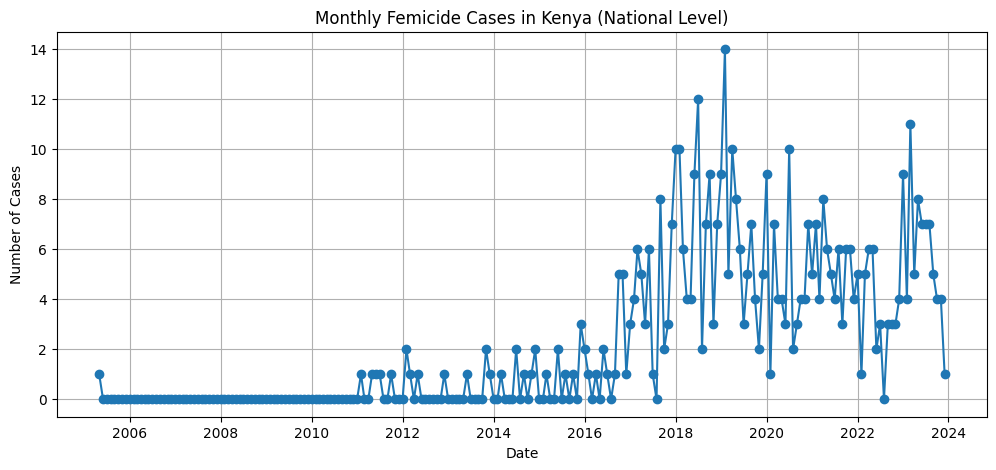

In [119]:
# Checking for continuity through a line plot

plt.figure(figsize=(12, 5))
plt.plot(monthly_cases.index, monthly_cases['cases'], marker='o', linestyle='-')
plt.title("Monthly Femicide Cases in Kenya (National Level)")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.grid(True)
plt.show()


In [120]:
# Saving the new monthly cases to national_monthly_cases.csv

monthly_cases.to_csv('../Data/Processed/national_monthly_cases.csv')

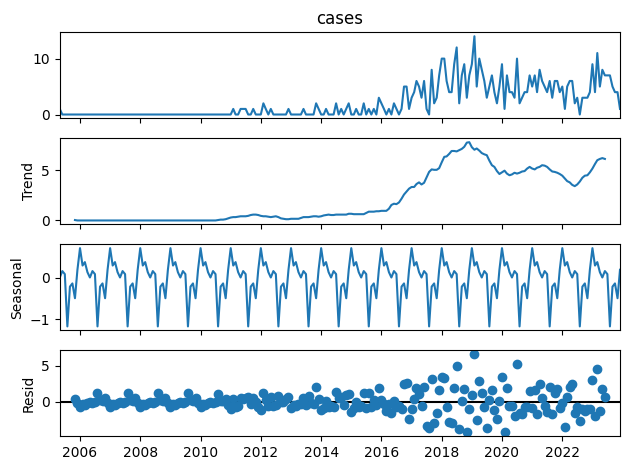

In [121]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose with additive model (cases are counts)
decomposition = seasonal_decompose(monthly_cases['cases'], model='additive')

# Plot the decomposition
decomposition.plot()
plt.show()
